In [1]:
import warnings

import pandas as pd

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pertpy as pt
import scanpy as sc
import seaborn as sns

In [2]:
# Load in data

# import preprocessed dataset

dir = "PBMC_datasets/4/PBMC4_clustering.h5ad"

adata = sc.read(dir)

In [3]:
# Compositional analysis (using scCODA)

#instantiate scCODA model and create MuData object 

sccoda_model = pt.tl.Sccoda()
sccoda_data = sccoda_model.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="celltypist_cell_label_coarse",
    sample_identifier="sample",
    covariate_obs=["diagnosis"],
)
sccoda_data

MuData object with n_obs × n_vars = 270934 × 19536
  var:	'n_cells'
  2 modalities
    rna:	270884 x 19528
      obs:	'prefix', 'sample', 'gsm_id', 'diagnosis', 'age', 'gender', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
      var:	'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'diagnosis_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res2', 'leiden_res2_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	50 x 8
      obs:	'sample', 'diagnosis'
      var:	'n_cells'

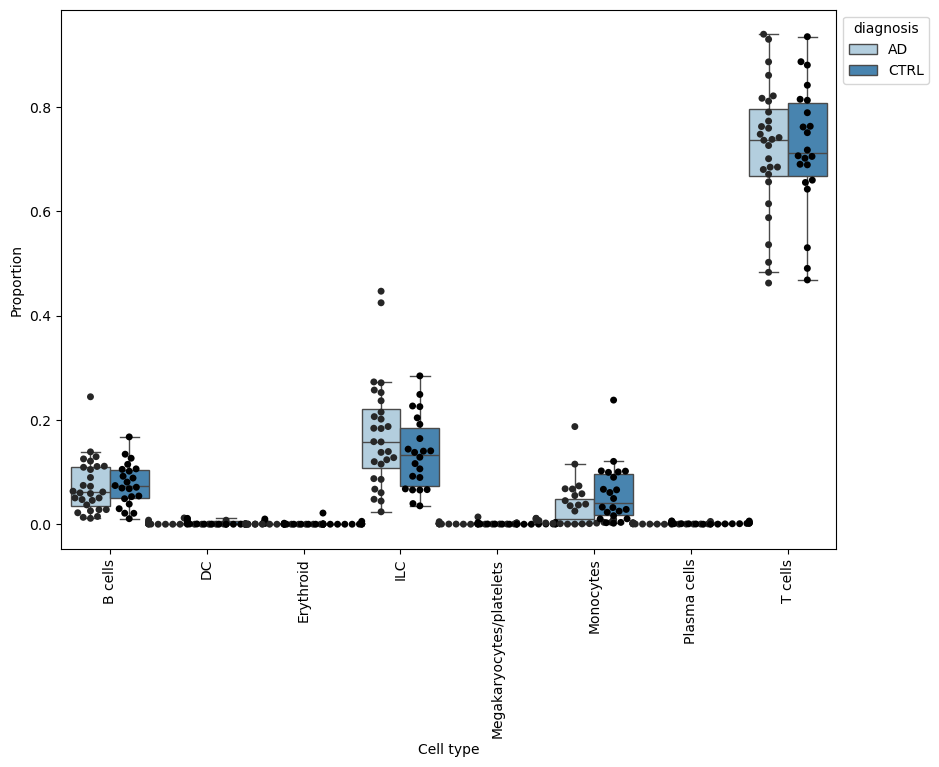

In [4]:
# get overview of cell type distributions w boxplots
sccoda_model.plot_boxplots(
    sccoda_data,
    modality_key="coda",
    feature_name="diagnosis",
    figsize=(10, 7),
    add_dots=True,
    args_swarmplot={"color": "red"},
)
plt.show()

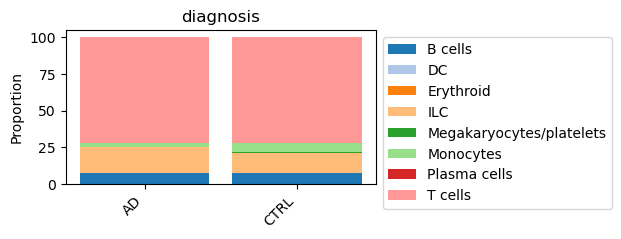

In [5]:
# alternative visualisation with stacked barplot

sccoda_model.plot_stacked_barplot(
    sccoda_data, modality_key="coda", feature_name="diagnosis", figsize=(4, 2)
)
plt.show()

In [6]:
# checking the baseline category for diagnosis (for interpretation of results later on)
sccoda_data["coda"].obs["diagnosis"].cat.categories

Index(['AD', 'CTRL'], dtype='object')

In [7]:
# change so that CTRL is the baseline category (for interpretation of results later on)
sccoda_data["coda"].obs["diagnosis"] = sccoda_data["coda"].obs["diagnosis"].cat.reorder_categories(
    ["CTRL", "AD"]
)
sccoda_data["coda"].obs["diagnosis"].cat.categories

Index(['CTRL', 'AD'], dtype='object')

In [8]:
# run scCODA model
sccoda_data = sccoda_model.prepare(
    sccoda_data,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
)
sccoda_model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [02:30<00:00, 72.99it/s, 127 steps of size 2.74e-02. acc. prob=0.84]


In [9]:
sccoda_data["coda"].varm["effect_df_diagnosis[T.AD]"]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_coarse,,,,,,,
B cells,0.0,-0.374,0.196,0.094,0.3686,405.285836,0.0
DC,0.0,-0.556,0.257,0.153,0.4309,47.731549,0.0
Erythroid,0.0,-0.524,0.282,0.147,0.4200,35.573201,0.0
ILC,0.0,-0.075,0.373,0.108,0.4416,755.660790,0.0
Megakaryocytes/platelets,0.0,-0.314,0.455,0.127,0.3864,46.089842,0.0
Monocytes,0.0,-0.960,0.007,0.287,0.9244,225.561441,0.0
Plasma cells,0.0,-0.490,0.284,0.138,0.4143,53.175225,0.0
T cells,0.0,0.000,0.000,0.000,0.0000,3849.092116,0.0


In [10]:
# from the above table, it seems none of the cell types are significantly differentially abundant between the two conditions (since all 95% credible intervals include 0). At FDR 0.05

In [11]:
# trying with a less stringent FDR threshold to see if any cell types are identified as differentially abundant
sccoda_model.set_fdr(sccoda_data, 0.2)
credible = sccoda_model.credible_effects(sccoda_data, modality_key="coda")
credible
# under this FDR threshold, it looks like monocytes are identified as significantly differentially abundant.

Covariate        Cell Type               
diagnosis[T.AD]  B cells                     False
                 DC                          False
                 Erythroid                   False
                 ILC                         False
                 Megakaryocytes/platelets    False
                 Monocytes                    True
                 Plasma cells                False
                 T cells                     False
Name: Final Parameter, dtype: bool

In [12]:
# identify significant cell types for downstream analyses

# dictionary for stars
significance_mapping = {
    celltype: "*"
    for (effect, celltype), is_sig in credible.items()
    if is_sig
}

In [13]:
significance_mapping

{'Monocytes': '*'}

In [14]:
# # plot relative abundances of cell types across the two conditions

# coda = sccoda_data["coda"]

# # counts -> dataframe
# df = pd.DataFrame(
#     coda.X,
#     index=coda.obs_names,
#     columns=coda.var_names
# )

# # relative abundances
# df = df.div(df.sum(axis=1), axis=0) * 100

# # add group label
# df["diagnosis"] = coda.obs["diagnosis"].values

# # long format
# plot_df = df.reset_index(names="sample").melt(
#     id_vars=["sample", "diagnosis"],
#     var_name="cell_type",
#     value_name="rel_abundance"
# )

# fig, ax = plt.subplots(figsize=(12, 6))
# sns.barplot(
#     data=plot_df,
#     x="cell_type",
#     y="rel_abundance",
#     hue="diagnosis",
#     errorbar=("ci", 95),
#     capsize = 0.1,
#     palette= "Paired"
# )
# sns.stripplot(
#     data=plot_df,
#     x="cell_type",
#     y="rel_abundance",
#     hue="diagnosis",
#     dodge=True,
#     color="black",
#     alpha=0.7,
#     size=2,
#     legend = False
# )

# for ct in significance_mapping.keys():
#     x = list(plot_df["cell_type"].unique()).index(ct)
#     y = plot_df.loc[plot_df["cell_type"] == ct, "rel_abundance"].max()
#     ax.text(x, y + 1, significance_mapping[ct], ha="center", fontsize=14)

# plt.xticks(rotation=30, ha="right")
# plt.ylabel("Relative abundance (%)")
# plt.xlabel("")
# plt.tight_layout()
# plt.show()


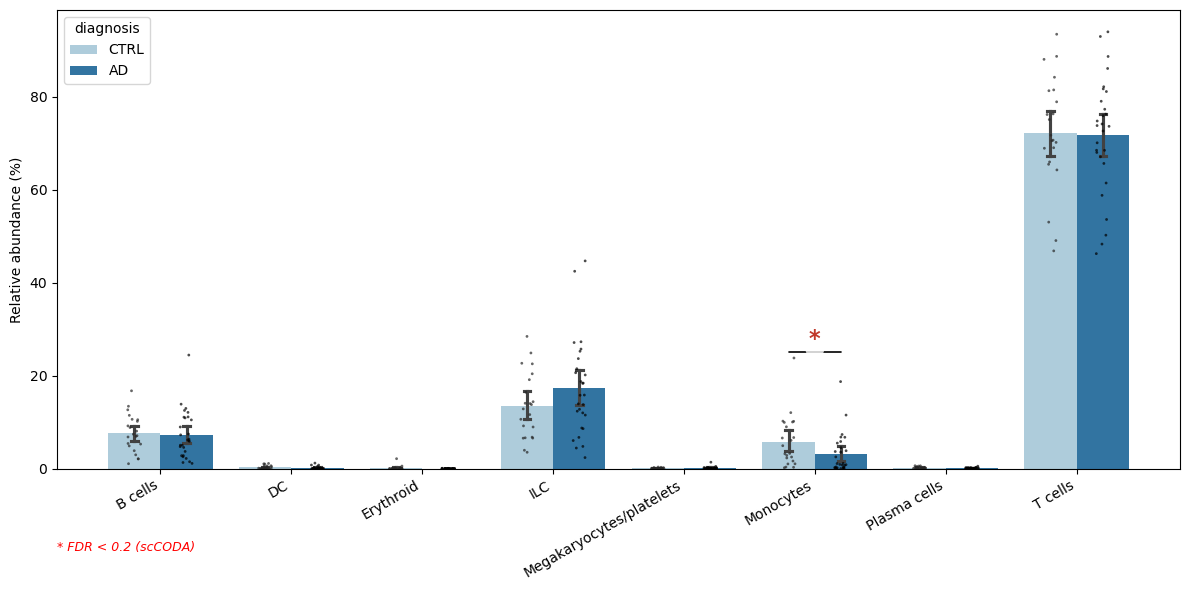

In [15]:
# plot relative abundances of cell types across the two conditions
coda = sccoda_data["coda"]

# Build relative-abundance long-format dataframe in one chain
plot_df = (
    pd.DataFrame(coda.X, index=coda.obs_names, columns=coda.var_names)
    .pipe(lambda df: df.div(df.sum(axis=1), axis=0) * 100)
    .assign(diagnosis=coda.obs["diagnosis"].values)
    .reset_index(names="sample")
    .melt(id_vars=["sample", "diagnosis"], var_name="cell_type", value_name="rel_abundance")
)

cell_types = plot_df["cell_type"].unique().tolist()

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=plot_df, x="cell_type", y="rel_abundance", hue="diagnosis",
    errorbar=("ci", 95), capsize=0.1, palette="Paired", ax=ax
)
sns.stripplot(
    data=plot_df, x="cell_type", y="rel_abundance", hue="diagnosis",
    dodge=True, color="black", alpha=0.7, size=2, legend=False, ax=ax
)

# Significance annotations 
PAD      = 1.2   # gap between bar top and bracket
TXT_PAD  = 0.4   # gap between bracket and asterisk

for ct, label in significance_mapping.items():
    x   = cell_types.index(ct)
    top = plot_df.loc[plot_df["cell_type"] == ct, "rel_abundance"].max()
    y_bracket = top + PAD
    y_text    = y_bracket + TXT_PAD

    # horizontal bracket line
    ax.plot(
        [x - 0.2, x + 0.2], [y_bracket, y_bracket],
        color="black", linewidth=1.2, solid_capstyle="round"
    )
    # asterisk with bold weight + contrasting background box
    ax.text(
        x, y_text, label,
        ha="center", va="bottom", fontsize=16, fontweight="bold", color="#C0392B",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)
    )

ax.annotate(
    "* FDR < 0.2 (scCODA)",
    xy=(0, -0.18), xycoords="axes fraction",
    fontsize=9, color="red", style="italic"
)

ax.set_xlabel("")
ax.set_ylabel("Relative abundance (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



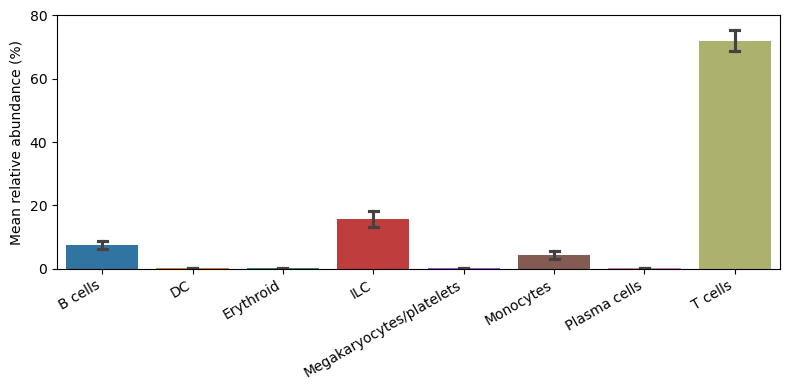

In [16]:
# plot overall relative abundance of each cell type across all samples with 95% CI, and colors corresponding to the cell types in UMAP

# count cells per type per sample, then normalise to %
plot_df = (
    adata.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

# derive colors from adata
labels = adata.obs["celltypist_cell_label_coarse"].astype("category").cat.categories
colors = adata.uns["celltypist_cell_label_coarse_colors"]
cell_type_colors_dict = dict(zip(labels, colors))

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="celltypist_cell_label_coarse",  # was "cell_type" — column doesn't exist yet
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 20))
plt.tight_layout()
plt.show()

In [17]:
adata

AnnData object with n_obs × n_vars = 270884 × 19528
    obs: 'prefix', 'sample', 'gsm_id', 'diagnosis', 'age', 'gender', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'diagnosis_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_

In [18]:
# recalculate relative abundance just for controls samples

ctrl_data = adata[adata.obs["diagnosis"] == "CTRL"]

ctrl_plot_df = (
    ctrl_data.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

ctrl_plot_df

,sample,celltypist_cell_label_coarse,count,rel_abundance
0,598,B cells,431,6.937067
1,598,DC,1,0.016095
2,598,Erythroid,1,0.016095
3,598,ILC,1268,20.408820
4,598,Megakaryocytes/platelets,14,0.225334
...,...,...,...,...
171,1282,ILC,867,14.070107
172,1282,Megakaryocytes/platelets,3,0.048685
173,1282,Monocytes,12,0.194742
174,1282,Plasma cells,6,0.097371


In [19]:
# check that the control relative abdunaces values add up to 100% for each sample

ctrl_plot_df.groupby("sample")["rel_abundance"].sum()

sample
598     100.0
780     100.0
781     100.0
820     100.0
836     100.0
905     100.0
911     100.0
912     100.0
968     100.0
970     100.0
978     100.0
989     100.0
1010    100.0
1020    100.0
1028    100.0
1111    100.0
1162    100.0
1180    100.0
1200    100.0
1273    100.0
1279    100.0
1282    100.0
Name: rel_abundance, dtype: float64

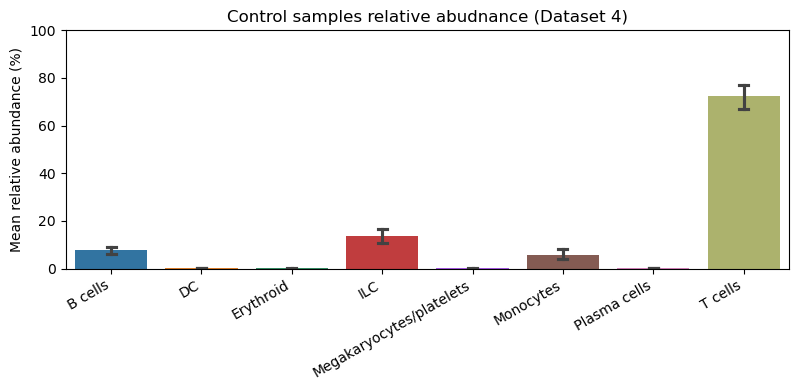

In [ ]:
# plot just the control samples:

plt.figure(figsize=(8, 4))
sns.barplot(
    data=ctrl_plot_df,
    x="celltypist_cell_label_coarse",
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.title("Control samples relative abudnance (Dataset 4)")
plt.tight_layout()
plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 20))
plt.show()


In [21]:
# Compare numerical differences between all samples and control-only samples

# Calculate mean relative abundance by cell type
all_samples_mean = plot_df.groupby("celltypist_cell_label_coarse")["rel_abundance"].mean()
ctrl_only_mean = ctrl_plot_df.groupby("celltypist_cell_label_coarse")["rel_abundance"].mean()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "All samples (%)": all_samples_mean,
    "Control only (%)": ctrl_only_mean,
})
comparison_df["Difference (%)"] = comparison_df["All samples (%)"] - comparison_df["Control only (%)"]
comparison_df = comparison_df.sort_values("Difference (%)", ascending=False)

print("Cell type composition comparison:\n")
print(comparison_df.round(2))


Cell type composition comparison:

                              All samples (%)  Control only (%)  \
celltypist_cell_label_coarse                                      
ILC                                     15.64             13.55   
Megakaryocytes/platelets                 0.12              0.09   
Plasma cells                             0.16              0.21   
DC                                       0.22              0.29   
Erythroid                                0.07              0.15   
B cells                                  7.46              7.62   
T cells                                 72.02             72.27   
Monocytes                                4.32              5.83   

                              Difference (%)  
celltypist_cell_label_coarse                  
ILC                                     2.09  
Megakaryocytes/platelets                0.03  
Plasma cells                           -0.05  
DC                                     -0.07  
Erythroid   

In [22]:
# redo composition analysis with fine annotations 

sccoda_model2 = pt.tl.Sccoda()
sccoda_data2 = sccoda_model2.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="celltypist_cell_label_fine",
    sample_identifier="sample",
    covariate_obs=["diagnosis"],
)
sccoda_data2

MuData object with n_obs × n_vars = 270934 × 19547
  var:	'n_cells'
  2 modalities
    rna:	270884 x 19528
      obs:	'prefix', 'sample', 'gsm_id', 'diagnosis', 'age', 'gender', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
      var:	'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'diagnosis_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res2', 'leiden_res2_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	50 x 19
      obs:	'sample', 'diagnosis'
      var:	'n_cells'

In [23]:
# run scCODA model
sccoda_data2 = sccoda_model2.prepare(
    sccoda_data2,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
)
sccoda_model2.run_nuts(sccoda_data2, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [04:40<00:00, 39.25it/s, 127 steps of size 3.27e-02. acc. prob=0.85]


In [24]:
# Safely access the effect dataframe for diagnosis (handles different reference naming)
varm = sccoda_data2["coda"].varm
effect_keys = [k for k in varm.keys() if k.startswith("effect_df_diagnosis")]
# if not effect_keys:
# 	raise KeyError(f"No 'effect_df_diagnosis*' key found in varm. Available keys: {list(varm.keys())}")
# # use the first matching key (e.g. 'effect_df_diagnosis[T.CTRL]' or similar)
varm[effect_keys[0]]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_fine,,,,,,,
Age-associated B cells,0.0,-0.264,0.295,0.099,0.4722,55.991653,0.0
CD16+ NK cells,0.0,-0.328,0.083,0.095,0.5113,789.344319,0.0
Classical monocytes,0.0,-0.067,0.675,0.221,0.7449,134.585896,0.0
DC2,0.0,-0.200,0.403,0.116,0.4860,44.710243,0.0
ILC3,0.0,-0.302,0.281,0.104,0.4765,39.377817,0.0
Late erythroid,0.0,-0.219,0.377,0.113,0.4846,33.388203,0.0
MAIT cells,0.0,-0.233,0.289,0.094,0.4706,152.811116,0.0
Megakaryocytes/platelets,0.0,-0.302,0.278,0.104,0.4778,45.295271,0.0
Memory B cells,0.0,-0.180,0.363,0.109,0.4927,175.598936,0.0


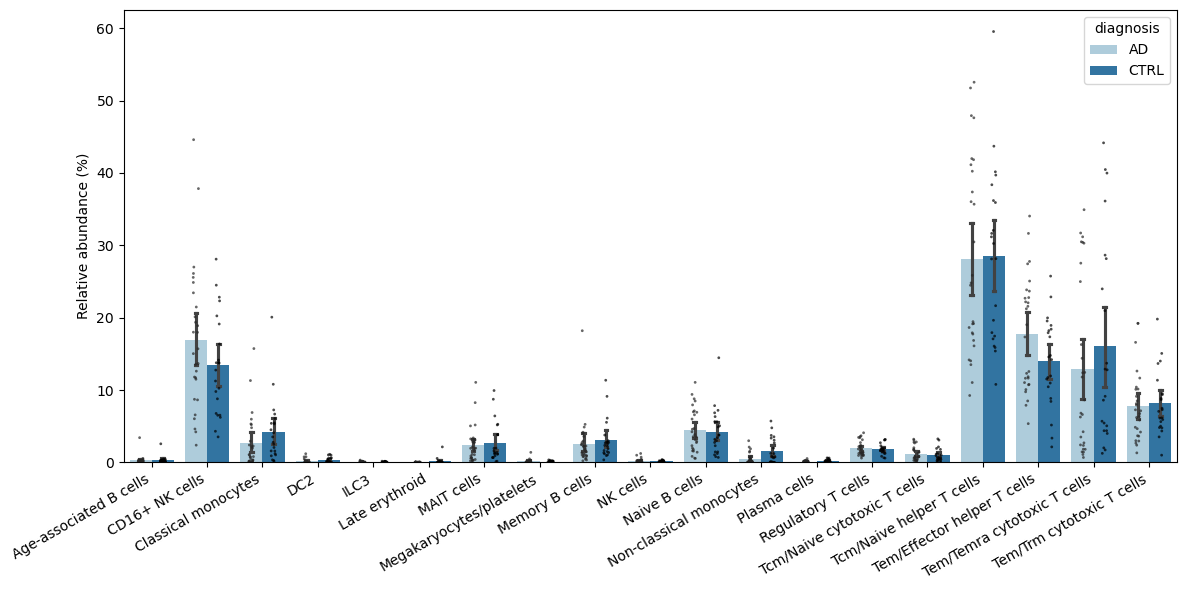

In [25]:
# plot relative abundances of cell types across the two conditions

coda = sccoda_data2["coda"]

# counts -> dataframe
df = pd.DataFrame(
    coda.X,
    index=coda.obs_names,
    columns=coda.var_names
)

# relative abundances
df = df.div(df.sum(axis=1), axis=0) * 100

# add group label
df["diagnosis"] = coda.obs["diagnosis"].values

# long format
plot_df = df.reset_index(names="sample").melt(
    id_vars=["sample", "diagnosis"],
    var_name="cell_type",
    value_name="rel_abundance"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    errorbar=("ci", 95),
    capsize = 0.1,
    palette= "Paired"
)
sns.stripplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    dodge=True,
    color="black",
    alpha=0.7,
    size=2,
    legend = False
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Relative abundance (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()


In [26]:
sccoda_model2.credible_effects(sccoda_data2, modality_key="coda")


Covariate          Cell Type                  
diagnosis[T.CTRL]  Age-associated B cells         False
                   CD16+ NK cells                 False
                   Classical monocytes            False
                   DC2                            False
                   ILC3                           False
                   Late erythroid                 False
                   MAIT cells                     False
                   Megakaryocytes/platelets       False
                   Memory B cells                 False
                   NK cells                       False
                   Naive B cells                  False
                   Non-classical monocytes        False
                   Plasma cells                   False
                   Regulatory T cells             False
                   Tcm/Naive cytotoxic T cells    False
                   Tcm/Naive helper T cells       False
                   Tem/Effector helper T cells    False
 

In [27]:
# trying with a less stringent FDR threshold to see if any cell types are identified as differentially abundant
sccoda_model2.set_fdr(sccoda_data2, 0.2)
credible = sccoda_model2.credible_effects(sccoda_data2, modality_key="coda")
credible


Covariate          Cell Type                  
diagnosis[T.CTRL]  Age-associated B cells         False
                   CD16+ NK cells                 False
                   Classical monocytes            False
                   DC2                            False
                   ILC3                           False
                   Late erythroid                 False
                   MAIT cells                     False
                   Megakaryocytes/platelets       False
                   Memory B cells                 False
                   NK cells                       False
                   Naive B cells                  False
                   Non-classical monocytes        False
                   Plasma cells                   False
                   Regulatory T cells             False
                   Tcm/Naive cytotoxic T cells    False
                   Tcm/Naive helper T cells       False
                   Tem/Effector helper T cells    False
 